# Create handwritten digits with GANs 


The <a href="https://arxiv.org/abs/1406.2661">GAN or Generative Adversarial Networks</a> are one of the latest advances in Deep Learning, the principle is quite simple. Instead of having one model that will generate images, we're going to have two models: 

* **A generator** : The first one is going to try to create images from the image dataset we give it. 
* **A discriminator**: Another model will try to distinguish the images created by the generator from the real images.

Everything is then a battle between the generator which will try to create images so perfect that the discriminator can no longer distinguish _true_ images from _generated_ images.

Let's try to implement this on MNIST: 

<img src="https://tensorflow.org/images/gan/dcgan.gif" />

In [54]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from torch.utils.data import DataLoader


device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [55]:
# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 28

# Number of channels in the training images. For color images this is 3
nc = 1

# Size of z latent vector (i.e. size of generator input)
latent_dim = 100

# Number of training epochs
num_epochs = 20

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 0

We need to download the MNIST dataset. You can do this via [`torchvision.datasets.MNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html)

In [56]:
# Define transformations for data augmentation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

In [57]:
data_root = "MNIST"
mnist = dset.MNIST(root=data_root,download=True, transform=transform)

In [58]:
# Load datasets with ImageFolder
train_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True)


Let's look at an element from `X_train`

In [59]:
imgs, labels = next(iter(train_loader))

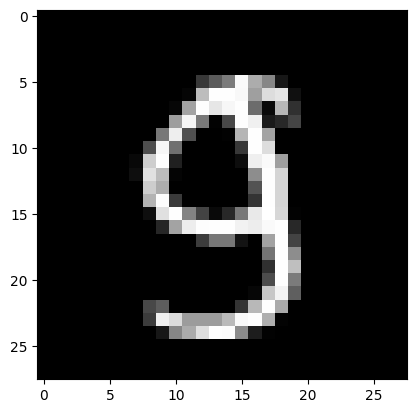

In [60]:
plt.imshow(imgs[0].squeeze(), cmap="gray")

In [61]:
imgs[0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

# Generator model

We create a generator model with an input shape of `100`, which means we will feed this model a vector of 100 random values (basically noise) and the model will have to output a tensor that has the same shape as our real data `(1,28,28,1)`.

To achieve this we will use a new layer: `nn.ConvTranspose2d` that is able to expand the input.

In [63]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.latent_dim = latent_dim

        self.main = nn.Sequential(
            # Fully connected layer to reshape input to a small spatial feature map
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            # Reshape to (128, 7, 7) for ConvTranspose2d layers
            nn.Unflatten(1, (128, 7, 7)),

            # Upsample to (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Upsample to (1, 28, 28)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Sigmoid()  # Outputs in range [0,1]
        )

    def forward(self, z):
        return self.main(z)

In [64]:
from torchinfo import summary
# Instantiate Generator
netG = Generator(latent_dim)

# Print model summary
summary(netG, input_size=(1, latent_dim))  # (batch_size, input_features)

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 633,472
│    └─BatchNorm1d: 2-2                  [1, 6272]                 12,544
│    └─ReLU: 2-3                         [1, 6272]                 --
│    └─Unflatten: 2-4                    [1, 128, 7, 7]            --
│    └─ConvTranspose2d: 2-5              [1, 64, 14, 14]           131,072
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─ConvTranspose2d: 2-8              [1, 1, 28, 28]            1,024
│    └─Sigmoid: 2-9                      [1, 1, 28, 28]            --
Total params: 778,240
Trainable params: 778,240
Non-trainable params: 0
Total mult-adds (M): 27.14
Input size (MB): 0.00
Forward/backward

Let's look at the details of this architecture

torch.Size([1, 1, 28, 28])


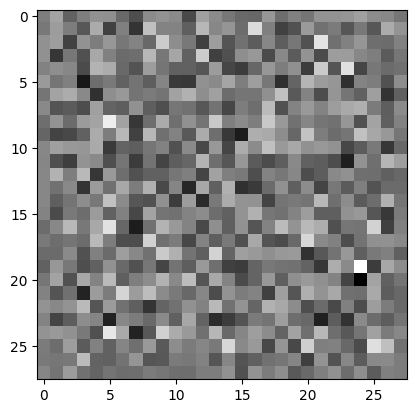

In [65]:
# 🔥 Example Usage
# Generate random latent input (batch_size, 100)
random_input = torch.randn(1, latent_dim).to(device)

### Model application
netG.eval() # prevent model from training
netG.to(device)
fake_images = netG(random_input)

### Model visualisation
plt.imshow(fake_images.cpu().detach().numpy().squeeze(), cmap="gray")

# Output shape
print(fake_images.shape)  # Expected: torch.Size([16, 1, 28, 28])


Now let's generate some random noise and feed it to this model to see what happens!

# Discriminator

The discriminator model is just a convolutional neural network classifier, let's build this model:

In [66]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            # First convolutional layer (input: 1 x 28 x 28 -> 64 x 14 x 14)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Second convolutional layer (64 x 14 x 14 -> 128 x 7 x 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Flatten and classify
            nn.Flatten(),  # (batch_size, 128 * 7 * 7)
            nn.Linear(128 * 7 * 7, 1),  # Fully connected layer (1 output: real/fake)
            nn.Sigmoid()  # Output probability in [0,1]
        )

    def forward(self, x):
        return self.main(x)

In [67]:
# 🔥 Example Usage
batch_size = 16

# Instantiate Discriminator
netD = Discriminator()

# Generate random fake images (batch_size, 1, 28, 28)
fake_images = torch.randn(batch_size, 1, 28, 28).to(device)

# Get Discriminator output (real/fake probability)
netD.eval()
netD.to(device)
output = netD(fake_images)

# Output shape
print(output.shape)  # Expected: torch.Size([16, 1])


torch.Size([16, 1])


In [68]:
from torchinfo import summary

# Print model summary
summary(netD, input_size=(1, 1, 28, 28))  # (batch_size, input_features)

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           1,024
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 128, 7, 7]            131,072
│    └─BatchNorm2d: 2-4                  [1, 128, 7, 7]            256
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Flatten: 2-6                      [1, 6272]                 --
│    └─Linear: 2-7                       [1, 1]                    6,273
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 138,625
Trainable params: 138,625
Non-trainable params: 0
Total mult-adds (M): 6.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.20
Params size (MB): 0.55
Estimated Total Size (MB): 0.76

# Loss functions

In order to build our loss functions we need to convert this unsupervised problem into a supervised one by assigning target values to real data and fake data on the fly. We will assign label `0` to fake data and `1` to real data for the discriminator loss, and `1` to fake data for the generator loss.

For this we will use two variables `real_label` and `fake_label`

In [69]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(16, latent_dim, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Training

Now let's prepare the model for training, since we have two different models to train, we need two different optimizers.

Note that the more difficult the distribution to model, the more sensitive to hyperparameters the model will become.

In [70]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

netD.to(device)
netG.to(device)

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, (data,label) in enumerate(train_loader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        # Create a variable full of ones for the real images label
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, latent_dim, device=device)
        # Generate fake image batch with G
        fake = netG(noise)

        # replace label variable with zero values
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        # Generate a new batch of latent vectors so both models do not train on similar examples
        # which could lead to overfitting
        noise2 = torch.randn(b_size, latent_dim, device=device)
        # Generate fake image batch with G
        fake2 = netG(noise2)
        output = netD(fake2).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(train_loader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(train_loader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/20][0/469]	Loss_D: 1.3924	Loss_G: 0.7799	D(x): 0.4882	D(G(z)): 0.4909 / 0.4585
[0/20][50/469]	Loss_D: 0.4536	Loss_G: 1.0760	D(x): 0.9777	D(G(z)): 0.3497 / 0.3415
[0/20][100/469]	Loss_D: 0.2956	Loss_G: 1.3992	D(x): 0.9939	D(G(z)): 0.2513 / 0.2469
[0/20][150/469]	Loss_D: 0.1579	Loss_G: 2.0245	D(x): 0.9941	D(G(z)): 0.1399 / 0.1359
[0/20][200/469]	Loss_D: 0.3184	Loss_G: 2.2880	D(x): 0.9056	D(G(z)): 0.1788 / 0.1161
[0/20][250/469]	Loss_D: 0.6880	Loss_G: 1.7417	D(x): 0.7504	D(G(z)): 0.2710 / 0.1944
[0/20][300/469]	Loss_D: 0.5866	Loss_G: 2.9636	D(x): 0.7815	D(G(z)): 0.2148 / 0.0748
[0/20][350/469]	Loss_D: 0.5549	Loss_G: 1.8374	D(x): 0.8285	D(G(z)): 0.2628 / 0.1964
[0/20][400/469]	Loss_D: 0.7244	Loss_G: 1.9253	D(x): 0.7786	D(G(z)): 0.3212 / 0.1959
[0/20][450/469]	Loss_D: 0.7022	Loss_G: 1.8542	D(x): 0.7451	D(G(z)): 0.2805 / 0.2032
[1/20][0/469]	Loss_D: 1.0792	Loss_G: 1.6789	D(x): 0.6633	D(G(z)): 0.3934 / 0.2307
[1/20][50/469]	Loss_D: 0.9268	Loss_G: 1.4767	D(x): 0.71

In [71]:
from plotly import graph_objects as go
color_chart = ["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]

fig = go.Figure(data=[
                      go.Scatter(
                          y=G_losses,
                          name="Generator Loss",
                          mode="lines",
                          marker=dict(
                              color=color_chart[0]
                          )),
                      go.Scatter(
                          y=D_losses,
                          name="Discriminator Loss",
                          mode="lines",
                          marker=dict(
                              color=color_chart[1]
                          ))
])
fig.update_layout(
    title='Training of the GAN',
    xaxis_title='epochs',
    yaxis_title='Cross Entropy'    
)
fig.show()

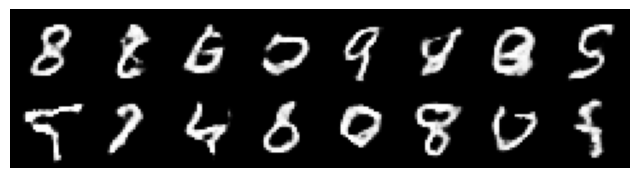

In [72]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

The results do not look too bad, now you can try playing arount with the hyper parameters, such as the smoothing of the labels etc in order to get more realistic images!